In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

2026-05-18 20:50:21.718712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779137421.995349      15 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779137422.073361      15 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779137422.828314      15 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779137422.828376      15 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779137422.828380      15 computation_placer.cc:177] computation placer alr

In [3]:
import os

print(os.listdir('/kaggle/input/datasets/paultimothymooney'))

['chest-xray-pneumonia']


In [4]:
print(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia'))

['chest_xray']


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
train_data = train_datagen.flow_from_directory(
    '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


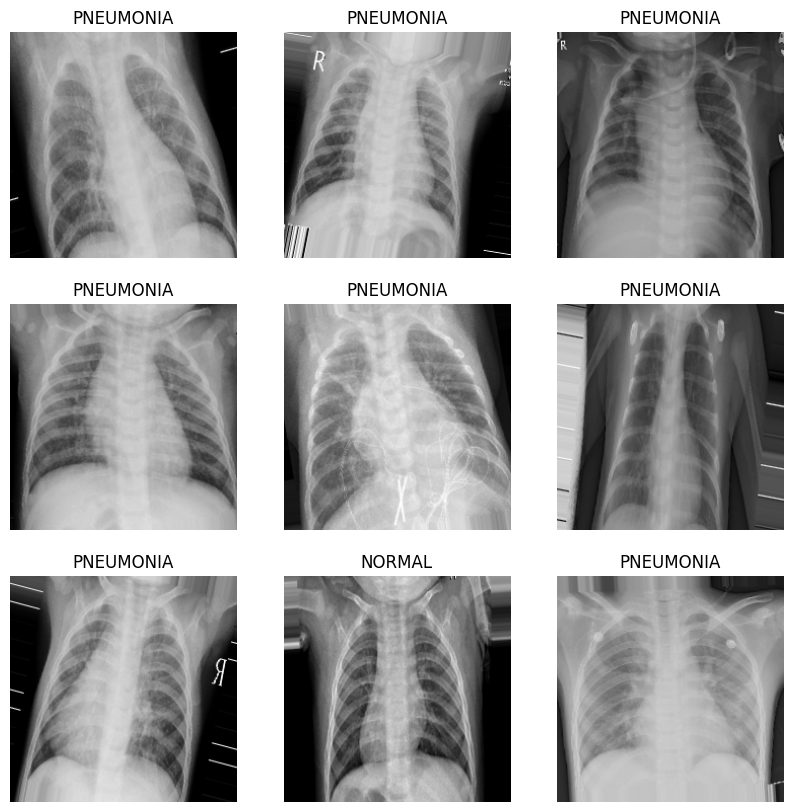

In [7]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    if labels[i] == 1:
        plt.title("PNEUMONIA")
    else:
        plt.title("NORMAL")

    plt.axis("off")

plt.show()

In [8]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

2026-05-18 20:51:04.619375: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')

])

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 222s 662ms/step - accuracy: 0.8683 - loss: 0.3132 - val_accuracy: 0.6250 - val_loss: 0.7976
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 185s 566ms/step - accuracy: 0.9374 - loss: 0.1550 - val_accuracy: 0.8750 - val_loss: 0.2769
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 190s 583ms/step - accuracy: 0.9371 - loss: 0.1520 - val_accuracy: 0.7500 - val_loss: 0.2683
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 186s 569ms/step - accuracy: 0.9416 - loss: 0.1421 - val_accuracy: 0.8125 - val_loss: 0.3291
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 199s 559ms/step - accuracy: 0.9536 - loss: 0.1269 - val_accuracy: 0.7500 - val_loss: 0.4967
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 202s 559ms/step - accuracy: 0.9513 - loss: 0.1306 - val_accuracy: 0.8125 - val_loss: 0.3011
Epoch 7/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 185s 568ms/step - accuracy: 0.9349 - loss: 0.1445 - val_accuracy: 0.8125 - val_loss: 0.3466
Epoch 8/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 187s 571ms/step - accuracy: 0.9532 -

In [13]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 421ms/step - accuracy: 0.8519 - loss: 0.3686
Test Loss: 0.2662016451358795
Test Accuracy: 0.8958333134651184


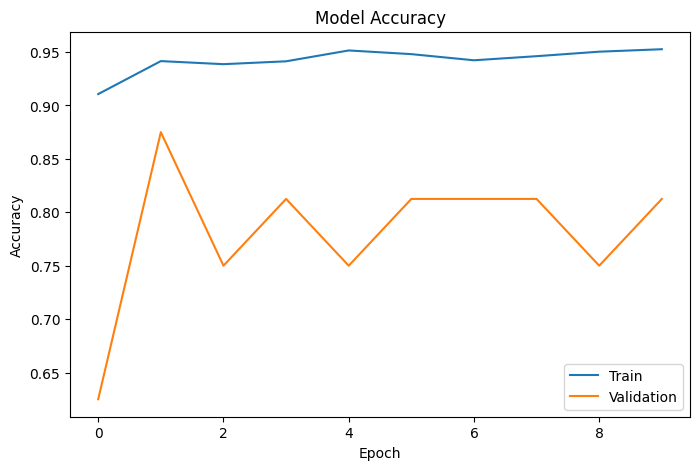

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

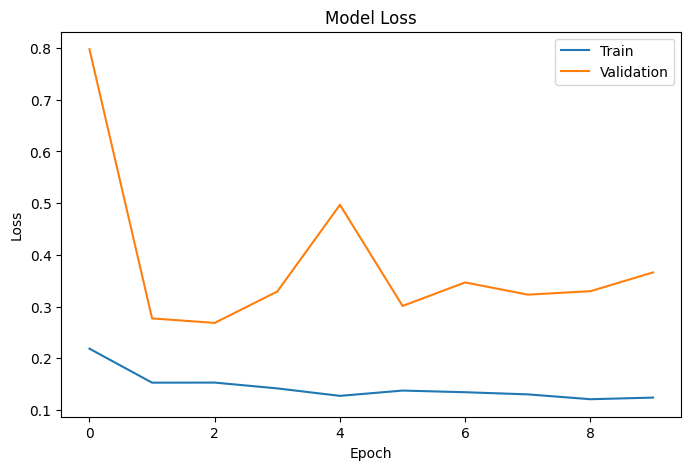

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [16]:
predictions = model.predict(test_data)

predicted_classes = []

for i in predictions:

    if i > 0.5:
        predicted_classes.append(1)
    else:
        predicted_classes.append(0)

39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 403ms/step


In [17]:
true_classes = test_data.classes

print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       234
           1       0.88      0.96      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.87      0.89       624
weighted avg       0.90      0.90      0.89       624



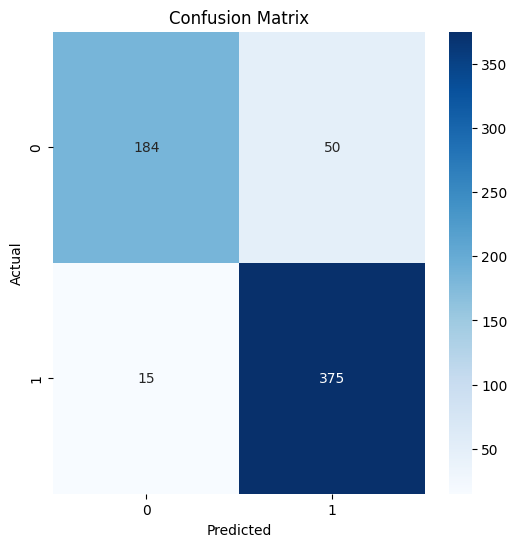

In [18]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [19]:
model.save("pneumonia_detection_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
from tensorflow.keras.models import load_model

loaded_model = load_model("pneumonia_detection_model.h5")

print("Model Loaded Successfully")

Model Loaded Successfully


In [21]:
from tensorflow.keras.preprocessing import image

img_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg'

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [22]:
prediction = loaded_model.predict(img_array)

if prediction[0][0] > 0.5:
    print("PNEUMONIA DETECTED")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
NORMAL


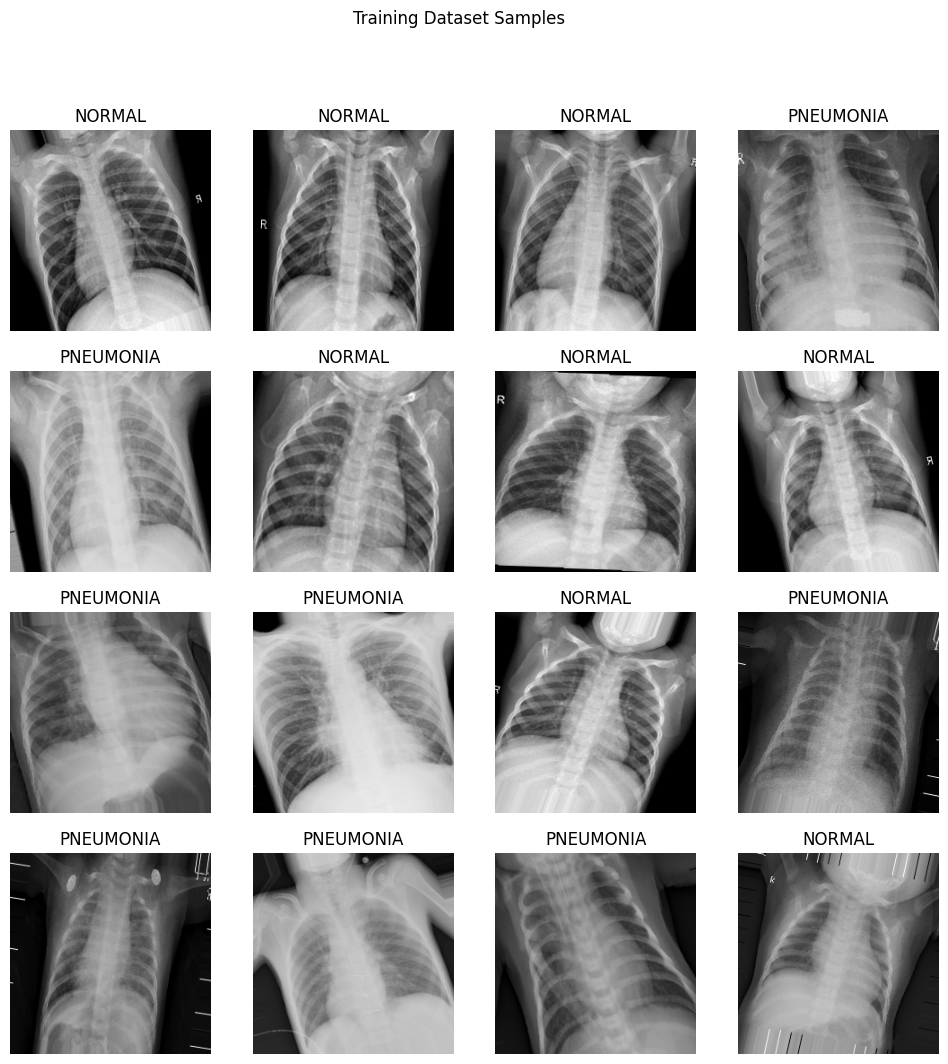

In [23]:
import random
import matplotlib.pyplot as plt

def show_images(generator, title):
    images, labels = next(generator)

    plt.figure(figsize=(12, 12))
    plt.suptitle(title)

    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.imshow(images[i])

        if labels[i] == 1:
            plt.title("PNEUMONIA")
        else:
            plt.title("NORMAL")

        plt.axis("off")

    plt.show()

show_images(train_data, "Training Dataset Samples")

In [24]:
import numpy as np

print("Train classes:", train_data.class_indices)

print("Test classes:", test_data.class_indices)

Train classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Test classes: {'NORMAL': 0, 'PNEUMONIA': 1}


In [25]:
import os

train_normal = len(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL'))
train_pneumonia = len(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA'))

print("Normal images:", train_normal)
print("Pneumonia images:", train_pneumonia)

Normal images: 1341
Pneumonia images: 3875


In [26]:
prediction = loaded_model.predict(img_array)

print("Model confidence:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("PNEUMONIA")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Model confidence: 0.0031769476
NORMAL


In [27]:
import numpy as np

wrong = 0

for i in range(len(predictions)):
    if predicted_classes[i] != true_classes[i]:
        wrong += 1

print("Wrong predictions:", wrong)
print("Total samples:", len(true_classes))

Wrong predictions: 65
Total samples: 624
